In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset

# --! define known data properties
timeseries_len  = 201
timestep        = 0.001
dataset_dir     = 'cavity/10Hz'

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. displacement
# --! 2. velocity
# --! 3. rf field gradient squared
x_dims_n = 2
u_dims_n  = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                201        3
   valid     1000                201        3
    test      500                201        3


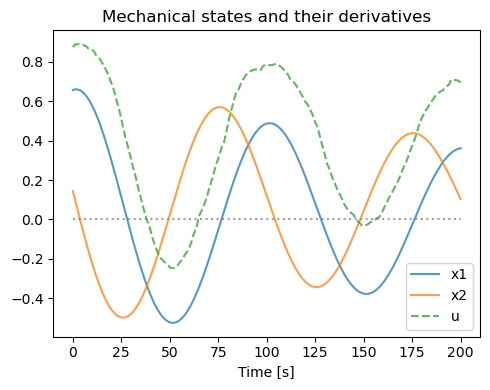

In [3]:
data_i = 123
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='x1')
plt.plot(data_viz[:, 1], color='tab:orange', alpha=0.75, label='x2')
plt.plot(data_viz[:, 2], color='tab:green', linestyle='dashed', alpha=0.75, label='u')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = care.detune()

inf >> Number of data files for training : 4
inf >> Processing training file number 1
inf >> Processing training file number 2
inf >> Processing training file number 3
inf >> Processing training file number 4


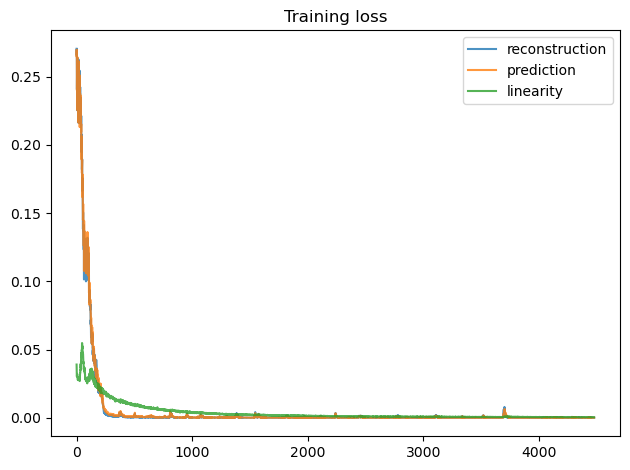

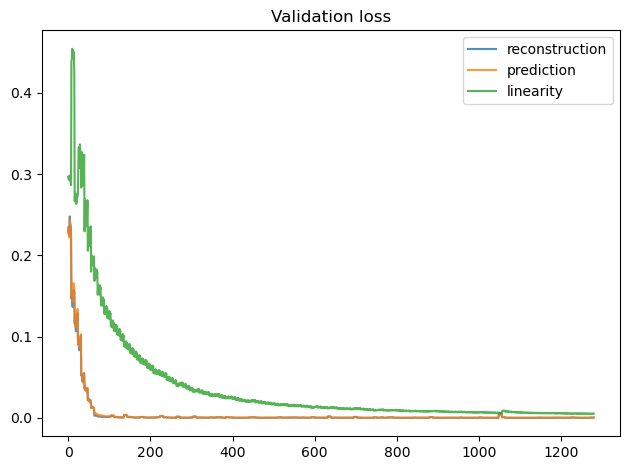

inf >> reconstruction loss in training is 5.610151e-03
inf >> prediction loss in training is 5.763729e-03
inf >> linearity loss in training is 4.002957e-03


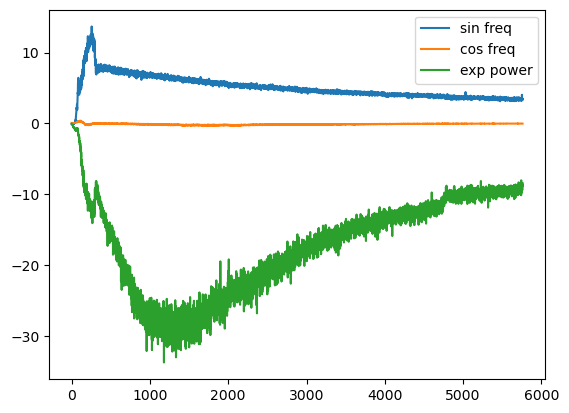

In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation

bat_sz = 128

# --! make validation datasets and loaders
dataset_valid = torch.utils.data.TensorDataset(data_valid)
dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)

# --! specify optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-8)

# --! empty arrays to gather statistics
loss_train_recon = []
loss_train_pred  = []
loss_train_lin   = []

loss_valid_recon = []
loss_valid_pred  = []
loss_valid_lin   = []

# --! training duration
datafiles_train_n = 4
epochs_n          = 40
print(f"inf >> Number of data files for training : {datafiles_train_n}")

for datafile_train in range(datafiles_train_n):
    print(f"inf >> Processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x  = data[0][:, :102, :1] # take only displacement
            u  = data[0][:, :102, x_dims_n:]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, loss_ae, loss_pred, loss_lin = model.fit(x)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_recon.append(loss_ae)
                loss_train_pred.append(loss_pred)
                loss_train_lin.append(loss_lin)

        # --! validate results
        with torch.no_grad():
            for data in dataloader_valid:
                x  = data[0][:, :102, :1] # take only displacement
                u  = data[0][:, :102, x_dims_n:]

                # --! validate prediction
                funs, funs_pred, timeseries_recon, timeseries_pred = model(x)
                loss_valid_recon.append(torch.mean((x - timeseries_recon)**2))
                loss_valid_pred.append(torch.mean((x - timeseries_pred)**2))
                loss_valid_lin.append(torch.mean((funs - funs_pred)**2))

# --! display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_recon, alpha=0.8, label='reconstruction')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin, alpha=0.8, label='linearity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_train_recon_mean = np.mean(loss_train_recon)
    loss_train_pred_mean = np.mean(loss_train_pred)
    loss_train_lin_mean = np.mean(loss_train_lin)
    print(f'inf >> reconstruction loss in training is {loss_train_recon_mean:e}')
    print(f'inf >> prediction loss in training is {loss_train_pred_mean:e}')
    print(f'inf >> linearity loss in training is {loss_train_lin_mean:e}')

    plt.figure()
    plt.plot(model.sin_freq, label='sin freq')
    plt.plot(model.cos_freq, label='cos freq')
    plt.plot(model.exp_power, label='exp power')
    plt.legend()
    plt.show()

In [6]:
with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_recon = []
    loss_test_pred = []

    for data in dataloader_test:
        x  = data[0][:, :102, :1]
        u  = data[0][:, :102, x_dims_n:]

        funs, funs_pred, timeseries_recon, timeseries_pred = model(x)
        loss_test_recon.append(torch.mean((x - timeseries_recon)**2))
        loss_test_pred.append(torch.mean((x - timeseries_pred)**2))

    loss_test_recon_mean = np.mean(loss_test_recon)
    loss_test_pred_mean = np.mean(loss_test_pred)
    # (torch.einsum) 1.533968e-04 -> (power mat) 1.297748e-04 -> (slice 50) 1.744521e-04 -> 2.908576e-05
    print(f'inf >> reconstruction loss in test is {loss_test_recon_mean:e}')
    # 2.632748e-03 -> 2.393762e-03 -> 9.944398e-04 -> 2.161562e-04
    print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}')

inf >> reconstruction loss in test is 2.942097e-04
inf >> prediction loss in test is 2.562255e-04


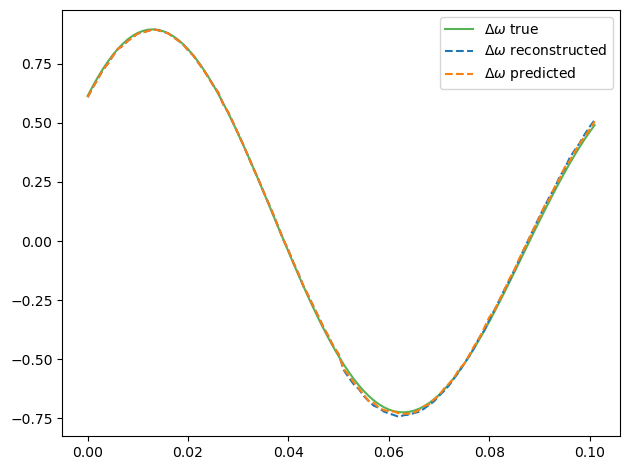

In [10]:
with torch.no_grad():
    data_i  = 123
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:102, :1], dim=0)
    funs, funs_pred, timeseries_recon, timeseries_pred = model(timeseries)

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_recon = torch.squeeze(timeseries_recon, dim=0)
    timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

    t = np.arange(0., 102*timestep, timestep)

    plt.figure()
    plt.plot(t, timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t, timeseries_recon[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ reconstructed')
    plt.plot(t, timeseries_pred[:, 0], alpha=1, color='tab:orange', linestyle='dashed', label='$\\Delta \\omega$ predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()